In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/zomato-eda/zomato.csv


In [2]:
df = pd.read_csv('/kaggle/input/zomato-eda/zomato.csv')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
df1=df.copy()

# Deleting redundant columns.

In [4]:
df1.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [5]:
df1 = df.drop(['url','phone','listed_in(city)','reviews_list','menu_item'],axis = 1)

# Renaming the columns.

In [6]:
df1.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [7]:
df1 = df1.rename(columns={
    'address':'ADDRESS',
    'name':'NAME',
    'online_order':'ONLINE_ORDERS_AVAILABILITY',
    'book_table':'TABLE_BOOKING',
    'rate':'RATINGS',
    'votes':'VOTES',
    'location':'LOCATION',
    'rest_type':'REST_EXP',
    'dish_liked':'SPECIAL_DISHES',
    'cuisines':'CUISINES',
    'approx_cost(for two people)':'APPROX_COST_TWO_PEOPLE',
    'listed_in(type)':'SERVING_TYPE'
    
})
df1

,ADDRESS,NAME,ONLINE_ORDERS_AVAILABILITY,TABLE_BOOKING,RATINGS,VOTES,LOCATION,REST_EXP,SPECIAL_DISHES,CUISINES,APPROX_COST_TWO_PEOPLE,SERVING_TYPE
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet
...,...,...,...,...,...,...,...,...,...,...,...,...
51712,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,Whitefield,Bar,NaN,Continental,"1,500",Pubs and bars
51713,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,Whitefield,Bar,NaN,Finger Food,600,Pubs and bars
51714,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Whitefield,Bar,NaN,Finger Food,"2,000",Pubs and bars
51715,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500",Pubs and bars


# Dropping duplicates.

In [8]:
df1.drop_duplicates(inplace=True)
print(df1)

                                                 ADDRESS  \
0      942, 21st Main Road, 2nd Stage, Banashankari, ...   
1      2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...   
2      1112, Next to KIMS Medical College, 17th Cross...   
3      1st Floor, Annakuteera, 3rd Stage, Banashankar...   
4      10, 3rd Floor, Lakshmi Associates, Gandhi Baza...   
...                                                  ...   
51712  Four Points by Sheraton Bengaluru, 43/3, White...   
51713  Number 10, Garudachar Palya, Mahadevapura, Whi...   
51714  Sheraton Grand Bengaluru Whitefield Hotel & Co...   
51715  Sheraton Grand Bengaluru Whitefield Hotel & Co...   
51716  ITPL Main Road, KIADB Export Promotion Industr...   

                                                    NAME  \
0                                                  Jalsa   
1                                         Spice Elephant   
2                                        San Churro Cafe   
3                                  Addh

# Cleaning individual columns.

In [9]:
df1[['ADDRESS', 'NAME', 'ONLINE_ORDERS_AVAILABILITY', 'TABLE_BOOKING',
       'RATINGS', 'VOTES','LOCATION', 'REST_EXP', 'SPECIAL_DISHES', 'CUISINES',
       'APPROX_COST_TWO_PEOPLE', 'SERVING_TYPE']].isnull().sum()

ADDRESS                           0
NAME                              0
ONLINE_ORDERS_AVAILABILITY        0
TABLE_BOOKING                     0
RATINGS                        3780
VOTES                             0
LOCATION                         14
REST_EXP                        156
SPECIAL_DISHES                17044
CUISINES                         33
APPROX_COST_TWO_PEOPLE          221
SERVING_TYPE                      0
dtype: int64

In [10]:
# Remove non-ASCII characters
df1['ADDRESS'] = df1['ADDRESS'].str.encode('ascii', 'ignore').str.decode('ascii')

In [11]:
df1['RATINGS'] = df1['RATINGS'].str.replace('/5','')

In [12]:
df1['RATINGS'] = df1['RATINGS'].str.replace('NEW','0.0')
df1['RATINGS'] = df1['RATINGS'].str.replace('-','0.0')

In [13]:
df1['RATINGS']

0         4.1
1         4.1
2         3.8
3         3.7
4         3.8
         ... 
51712    3.6 
51713     NaN
51714     NaN
51715    4.3 
51716    3.4 
Name: RATINGS, Length: 35151, dtype: object

In [14]:
df1['RATINGS'] = df1['RATINGS'].astype(float)

In [15]:
avg = df1['RATINGS'].mean()

In [16]:
avg

3.568678078480125

In [17]:
df1['RATINGS'] = df1['RATINGS'].fillna(avg)

In [18]:
df1['RATINGS'].isnull().sum()

0

In [19]:
df1['RATINGS']=df1['RATINGS'].apply(lambda x:round(x, 1))

In [20]:
df1['RATINGS']

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    3.6
51714    3.6
51715    4.3
51716    3.4
Name: RATINGS, Length: 35151, dtype: float64

In [21]:
df1['LOCATION'] = df1['LOCATION'].fillna(df1['LOCATION'].mode().values[0])

In [22]:
df1['LOCATION'].isnull().sum()

0

In [23]:
df1['LOCATION']

0                      Banashankari
1                      Banashankari
2                      Banashankari
3                      Banashankari
4                      Basavanagudi
                    ...            
51712                    Whitefield
51713                    Whitefield
51714                    Whitefield
51715    ITPL Main Road, Whitefield
51716    ITPL Main Road, Whitefield
Name: LOCATION, Length: 35151, dtype: object

In [24]:
df1['REST_EXP'] = df1['REST_EXP'].fillna( df1['REST_EXP'].mode().values[0])

In [25]:
df1['REST_EXP'].isnull().sum()

0

In [26]:
df1['REST_EXP']

0              Casual Dining
1              Casual Dining
2        Cafe, Casual Dining
3                Quick Bites
4              Casual Dining
                ...         
51712                    Bar
51713                    Bar
51714                    Bar
51715                    Bar
51716     Bar, Casual Dining
Name: REST_EXP, Length: 35151, dtype: object

In [27]:
df1['SPECIAL_DISHES'] = df1['SPECIAL_DISHES'].fillna(df1['SPECIAL_DISHES'].mode().values[0])

In [28]:
df1['SPECIAL_DISHES'].isnull().sum()

0

In [29]:
df1['SPECIAL_DISHES']

0        Pasta, Lunch Buffet, Masala Papad, Paneer Laja...
1        Momos, Lunch Buffet, Chocolate Nirvana, Thai G...
2        Churros, Cannelloni, Minestrone Soup, Hot Choc...
3                                              Masala Dosa
4                                      Panipuri, Gol Gappe
                               ...                        
51712                                              Biryani
51713                                              Biryani
51714                                              Biryani
51715                         Cocktails, Pizza, Buttermilk
51716                                              Biryani
Name: SPECIAL_DISHES, Length: 35151, dtype: object

In [30]:
df1['CUISINES'] = df1['CUISINES'].fillna(df1['CUISINES'].mode().values[0])

In [31]:
df1['CUISINES'].isnull().sum()

0

In [32]:
df1['CUISINES']

0                North Indian, Mughlai, Chinese
1                   Chinese, North Indian, Thai
2                        Cafe, Mexican, Italian
3                    South Indian, North Indian
4                      North Indian, Rajasthani
                          ...                  
51712                               Continental
51713                               Finger Food
51714                               Finger Food
51715                               Finger Food
51716    Finger Food, North Indian, Continental
Name: CUISINES, Length: 35151, dtype: object

In [33]:
df1['APPROX_COST_TWO_PEOPLE']=df1['APPROX_COST_TWO_PEOPLE'].str.replace(',','')

In [34]:
df1['APPROX_COST_TWO_PEOPLE']=df1['APPROX_COST_TWO_PEOPLE'].fillna(df1['APPROX_COST_TWO_PEOPLE'].astype(float).median())

In [35]:
df1['APPROX_COST_TWO_PEOPLE'].isnull().sum()

0

In [36]:
df1['APPROX_COST_TWO_PEOPLE']=df1['APPROX_COST_TWO_PEOPLE'].astype(int)

In [37]:
df1['APPROX_COST_TWO_PEOPLE']

0         800
1         800
2         800
3         300
4         600
         ... 
51712    1500
51713     600
51714    2000
51715    2500
51716    1500
Name: APPROX_COST_TWO_PEOPLE, Length: 35151, dtype: int64

# checking values in dataset

In [38]:
df1.isnull().sum()

ADDRESS                       0
NAME                          0
ONLINE_ORDERS_AVAILABILITY    0
TABLE_BOOKING                 0
RATINGS                       0
VOTES                         0
LOCATION                      0
REST_EXP                      0
SPECIAL_DISHES                0
CUISINES                      0
APPROX_COST_TWO_PEOPLE        0
SERVING_TYPE                  0
dtype: int64

In [39]:
df1

,ADDRESS,NAME,ONLINE_ORDERS_AVAILABILITY,TABLE_BOOKING,RATINGS,VOTES,LOCATION,REST_EXP,SPECIAL_DISHES,CUISINES,APPROX_COST_TWO_PEOPLE,SERVING_TYPE
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet
...,...,...,...,...,...,...,...,...,...,...,...,...
51712,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Biryani,Continental,1500,Pubs and bars
51713,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,3.6,0,Whitefield,Bar,Biryani,Finger Food,600,Pubs and bars
51714,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.6,0,Whitefield,Bar,Biryani,Finger Food,2000,Pubs and bars
51715,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,2500,Pubs and bars


In [40]:
df1

,ADDRESS,NAME,ONLINE_ORDERS_AVAILABILITY,TABLE_BOOKING,RATINGS,VOTES,LOCATION,REST_EXP,SPECIAL_DISHES,CUISINES,APPROX_COST_TWO_PEOPLE,SERVING_TYPE
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet
...,...,...,...,...,...,...,...,...,...,...,...,...
51712,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Biryani,Continental,1500,Pubs and bars
51713,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,3.6,0,Whitefield,Bar,Biryani,Finger Food,600,Pubs and bars
51714,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.6,0,Whitefield,Bar,Biryani,Finger Food,2000,Pubs and bars
51715,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,2500,Pubs and bars


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Restaurants delivering Online or not

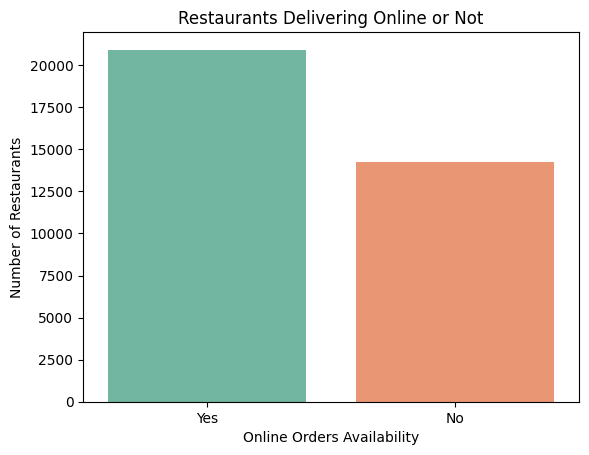

In [42]:
sns.countplot(x='ONLINE_ORDERS_AVAILABILITY', data=df1,palette="Set2")
plt.title("Restaurants Delivering Online or Not")
plt.xlabel('Online Orders Availability')
plt.ylabel('Number of Restaurants')
plt.show()

# Restaurants allowing table booking or not

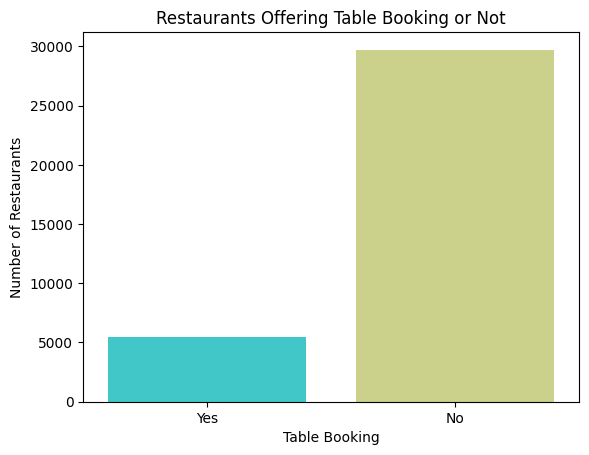

In [43]:
sns.countplot(x='TABLE_BOOKING',data=df1,palette='rainbow')
plt.title('Restaurants Offering Table Booking or Not')
plt.xlabel('Table Booking')
plt.ylabel('Number of Restaurants')
plt.show()

# Table booking Rate vs Rate


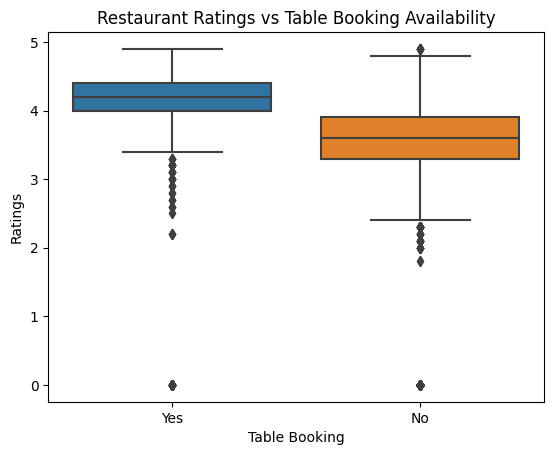

In [44]:
sns.boxplot(x='TABLE_BOOKING', y='RATINGS', data=df1)
plt.title("Restaurant Ratings vs Table Booking Availability")
plt.xlabel('Table Booking')
plt.ylabel('Ratings')
plt.show()

# Best Location


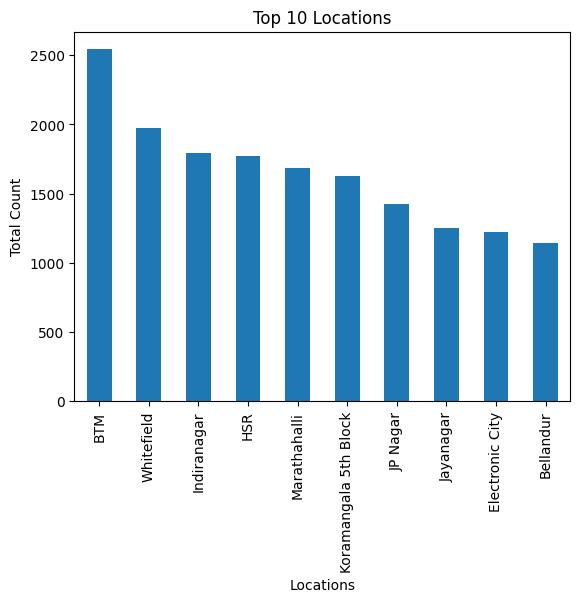

In [45]:
df1['LOCATION'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Locations")
plt.xlabel("Locations")
plt.ylabel("Total Count")
plt.show()


# Relation between Location and Rating

<Axes: xlabel='LOCATION', ylabel='RATINGS'>

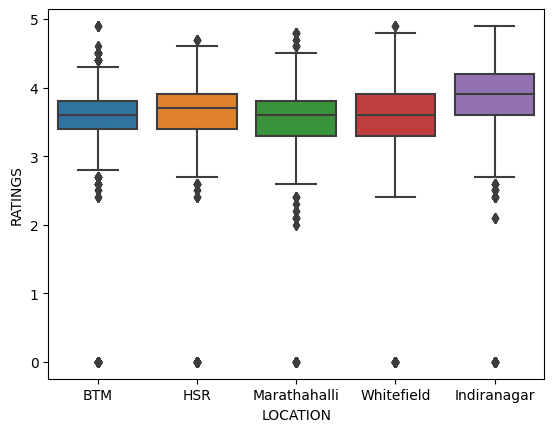

In [46]:
top_10_loc = df1['LOCATION'].value_counts().head(5).index
filt_df = df1[df1['LOCATION'].isin(top_10_loc)]
sns.boxplot(x='LOCATION',y='RATINGS',data=filt_df)

# Restaurant Type

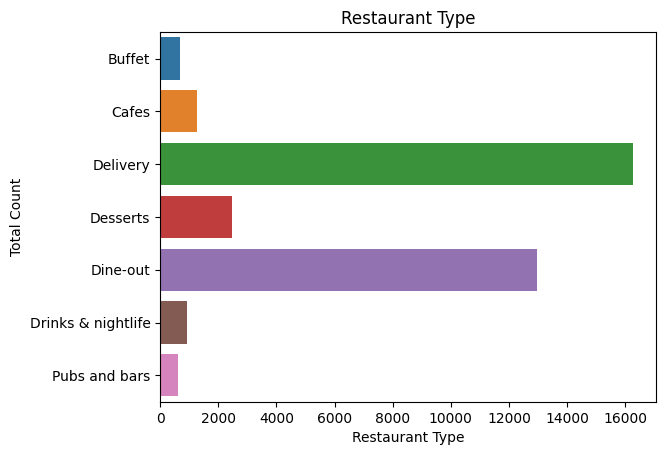

In [47]:
sns.countplot(y='SERVING_TYPE',data=df1)
plt.title('Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Total Count')
plt.show()

# Gaussian Rest type and Rating

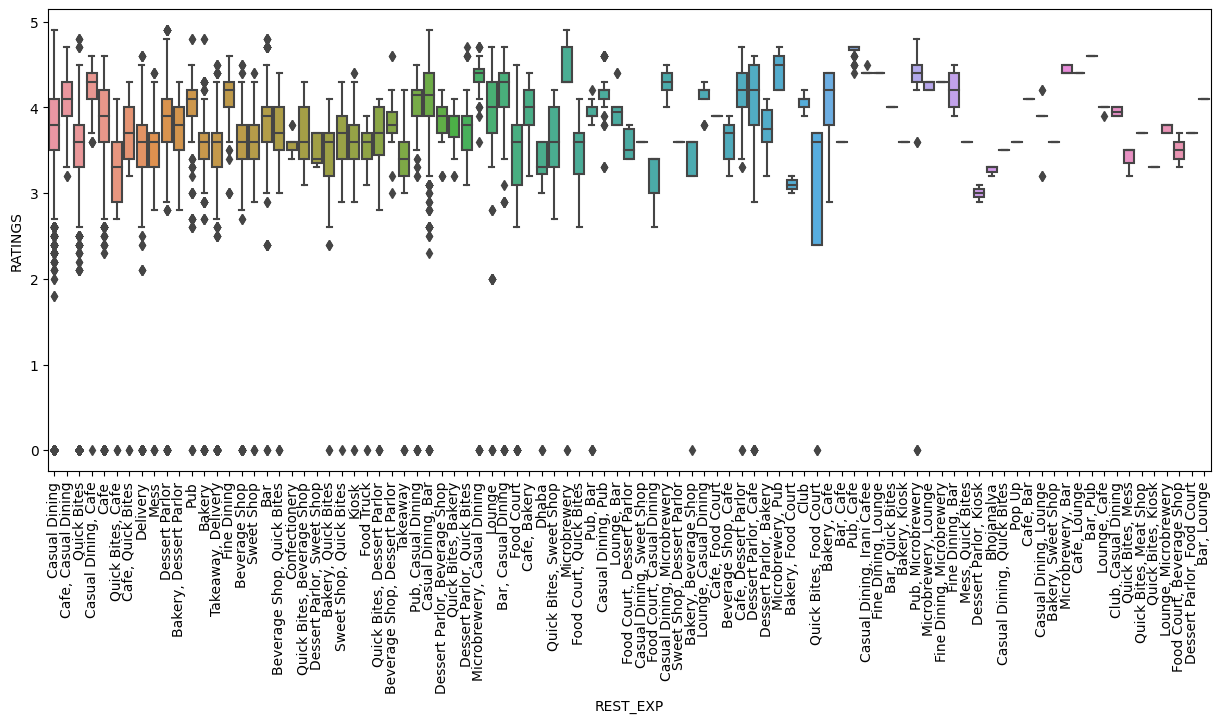

In [48]:
plt.figure(figsize=(15,6))
sns.boxplot(x='REST_EXP', y='RATINGS', data=df1)
plt.xticks(rotation=90)  
plt.show()


# Types of Services

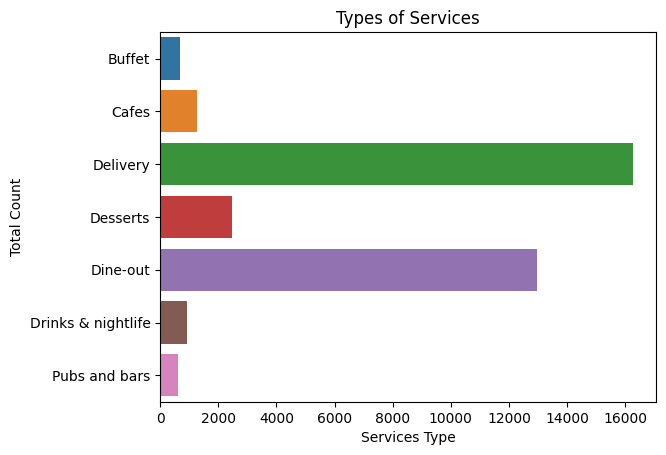

In [49]:
sns.countplot(y='SERVING_TYPE',data=df1)
plt.title('Types of Services')
plt.xlabel('Services Type')
plt.ylabel('Total Count')
plt.show()

# Cost of Restaurant

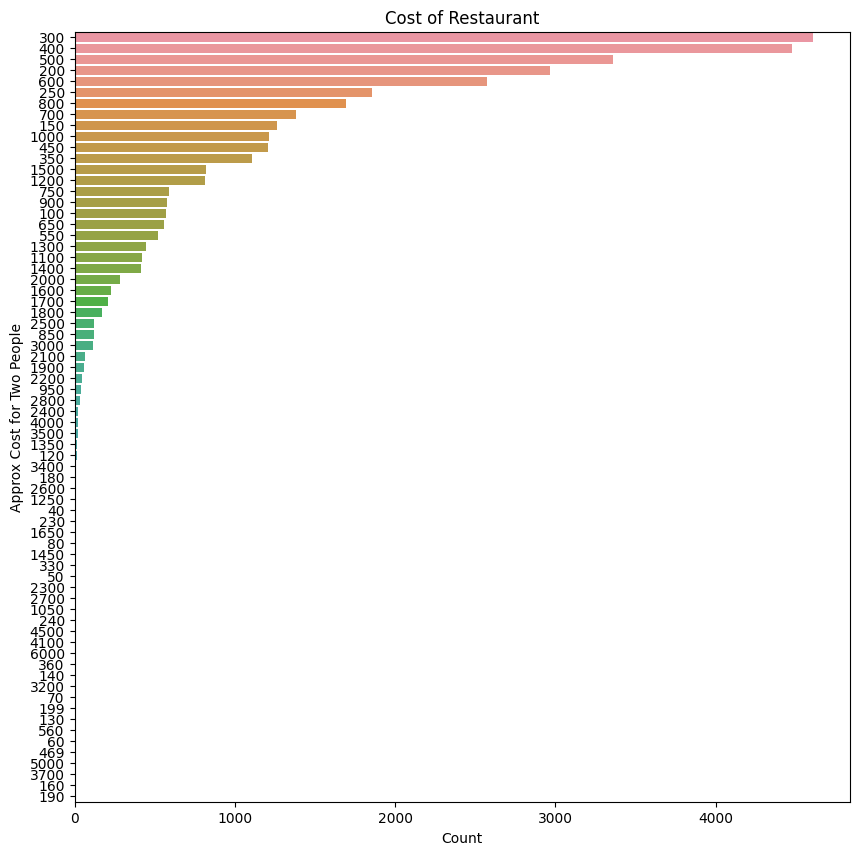

In [50]:
plt.figure(figsize=(10,10))
sns.countplot(y='APPROX_COST_TWO_PEOPLE', data=df1,
              order=df1['APPROX_COST_TWO_PEOPLE'].value_counts().index)
plt.title('Cost of Restaurant')
plt.xlabel('Count')
plt.ylabel('Approx Cost for Two People')
plt.show()



# No. of restaurants in a Location


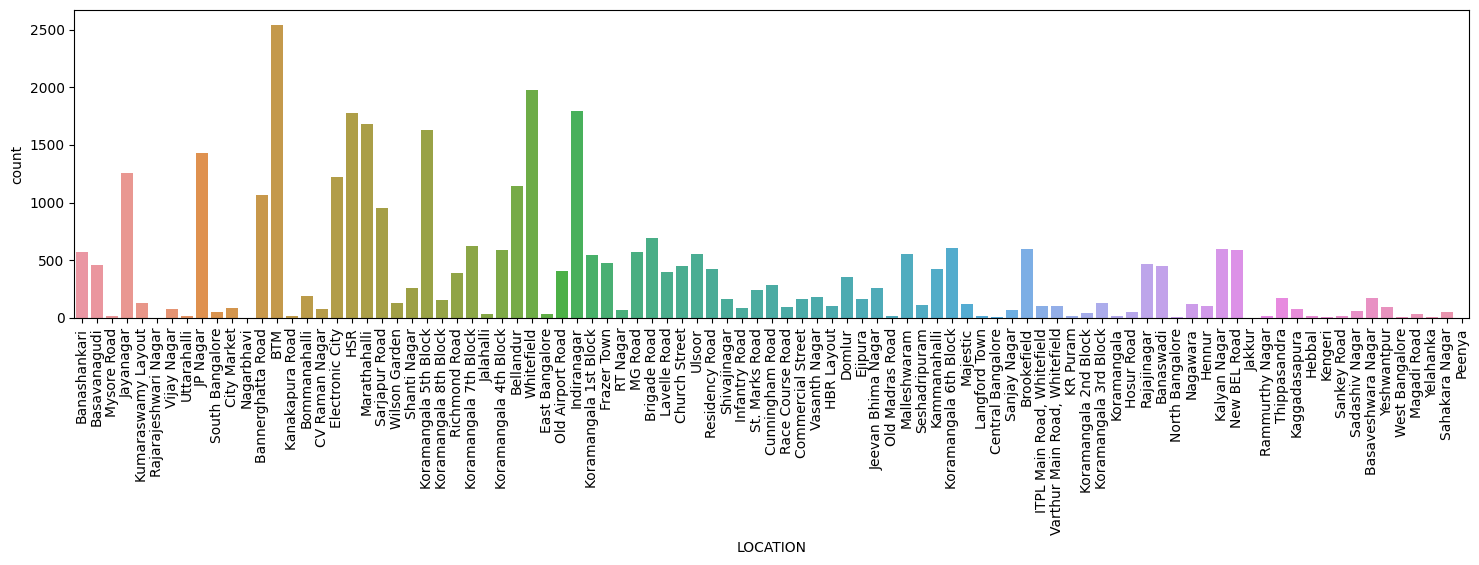

In [51]:
plt.figure(figsize=(18,4))
sns.countplot(x='LOCATION', data=df1)
plt.xticks(rotation=90)
plt.show()

# Most famous restaurant chains in Bengaluru


In [52]:
df1.columns

Index(['ADDRESS', 'NAME', 'ONLINE_ORDERS_AVAILABILITY', 'TABLE_BOOKING',
       'RATINGS', 'VOTES', 'LOCATION', 'REST_EXP', 'SPECIAL_DISHES',
       'CUISINES', 'APPROX_COST_TWO_PEOPLE', 'SERVING_TYPE'],
      dtype='object')

<Axes: xlabel='NAME,LOCATION'>

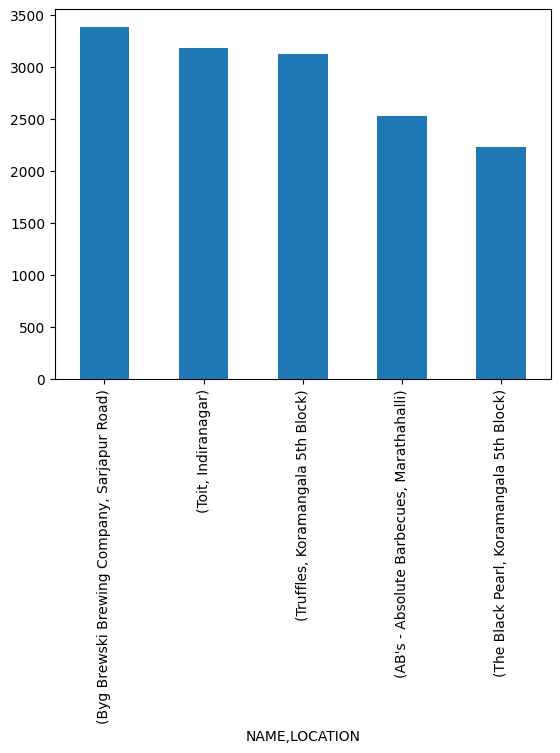

In [53]:
temp = df1.copy()

temp['v:r'] = temp['VOTES'] / temp['RATINGS']

temp.groupby(['NAME', 'LOCATION'])['v:r'].mean().sort_values(ascending = False).head(5).plot(kind = 'bar')